# Lab Assignment 3 - PCS221 Cloud Computing
**Name:** Simran  
**Roll No:** 8025320093  
**Group:** CS-02

## Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Part I: Randomized Sales Data Generation
### Step 1: Initialize Random Seed

In [2]:
ROLL_NUMBER = 8025320093
np.random.seed(ROLL_NUMBER % (2**32))
print(f"Random seed set to: {ROLL_NUMBER % (2**32)}")

Random seed set to: 3730352797


### Step 2: Generate Sales Data

In [3]:
sales_data = np.random.randint(1000, 5001, size=(12, 4))
print("Raw Sales Data (NumPy Array):")
print(sales_data)
print(f"\nShape: {sales_data.shape}")

Raw Sales Data (NumPy Array):
[[2052 1558 4723 2190]
 [2920 1685 3763 3245]
 [3586 2709 3276 3280]
 [3301 3781 3138 2687]
 [2861 4265 1890 1951]
 [1471 2239 2207 4274]
 [4451 1025 3894 2452]
 [1238 2485 4736 4195]
 [2160 1279 2736 2138]
 [4348 2271 2577 3544]
 [1636 3829 3603 4492]
 [1078 4220 4157 3044]]

Shape: (12, 4)


### Step 3: Convert to DataFrame

In [4]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
columns = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']

df = pd.DataFrame(sales_data, index=months, columns=columns)
print("Sales DataFrame:")
print(df)

Sales DataFrame:
     Electronics  Clothing  Home & Kitchen  Sports
Jan         2052      1558            4723    2190
Feb         2920      1685            3763    3245
Mar         3586      2709            3276    3280
Apr         3301      3781            3138    2687
May         2861      4265            1890    1951
Jun         1471      2239            2207    4274
Jul         4451      1025            3894    2452
Aug         1238      2485            4736    4195
Sep         2160      1279            2736    2138
Oct         4348      2271            2577    3544
Nov         1636      3829            3603    4492
Dec         1078      4220            4157    3044


## Part II: Data Manipulation and Analysis (Pandas)
### Step 1: First 5 rows and summary statistics

In [5]:
print("First 5 rows:")
print(df.head())
print("\nSummary Statistics:")
print(df.describe())

First 5 rows:
     Electronics  Clothing  Home & Kitchen  Sports
Jan         2052      1558            4723    2190
Feb         2920      1685            3763    3245
Mar         3586      2709            3276    3280
Apr         3301      3781            3138    2687
May         2861      4265            1890    1951

Summary Statistics:
       Electronics     Clothing  Home & Kitchen       Sports
count    12.000000    12.000000       12.000000    12.000000
mean   2591.833333  2612.166667     3391.666667  3124.333333
std    1167.140705  1156.498385      925.892624   875.202557
min    1078.000000  1025.000000     1890.000000  1951.000000
25%    1594.750000  1653.250000     2696.250000  2386.500000
50%    2510.500000  2378.000000     3439.500000  3144.500000
75%    3372.250000  3793.000000     3959.750000  3706.750000
max    4451.000000  4265.000000     4736.000000  4492.000000


### Step 2: Total Sales per Category and per Month

In [6]:
total_per_category = df.sum()
print("Total Sales per Category:")
print(total_per_category)

total_per_month = df.sum(axis=1)
print("\nTotal Sales per Month:")
print(total_per_month)

Total Sales per Category:
Electronics       31102
Clothing          31346
Home & Kitchen    40700
Sports            37492
dtype: int64

Total Sales per Month:
Jan    10523
Feb    11613
Mar    12851
Apr    12907
May    10967
Jun    10191
Jul    11822
Aug    12654
Sep     8313
Oct    12740
Nov    13560
Dec    12499
dtype: int64


### Step 3: Average Sales Growth Between Consecutive Months

In [7]:
avg_growth = df.diff().mean()
print("Average Sales Growth Between Consecutive Months (per category):")
print(avg_growth)

Average Sales Growth Between Consecutive Months (per category):
Electronics       -88.545455
Clothing          242.000000
Home & Kitchen    -51.454545
Sports             77.636364
dtype: float64


### Step 4: Add Total Sales and Growth Rate Columns

In [8]:
df['Total Sales'] = df[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']].sum(axis=1)
df['Growth Rate'] = df['Total Sales'].pct_change() * 100
print("DataFrame with Total Sales and Growth Rate:")
print(df.round(2))

DataFrame with Total Sales and Growth Rate:
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         2052      1558            4723    2190        10523          NaN
Feb         2920      1685            3763    3245        11613        10.36
Mar         3586      2709            3276    3280        12851        10.66
Apr         3301      3781            3138    2687        12907         0.44
May         2861      4265            1890    1951        10967       -15.03
Jun         1471      2239            2207    4274        10191        -7.08
Jul         4451      1025            3894    2452        11822        16.00
Aug         1238      2485            4736    4195        12654         7.04
Sep         2160      1279            2736    2138         8313       -34.31
Oct         4348      2271            2577    3544        12740        53.25
Nov         1636      3829            3603    4492        13560         6.44
Dec         1078      4220      

### Step 5: Apply Randomized Discount
Roll number **8025320093** is **odd** → apply **15% discount to Clothing**

In [9]:
# Roll number 8025320093 is ODD → 15% discount on Clothing
df['Clothing'] = df['Clothing'] * 0.85
df['Total Sales'] = df[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']].sum(axis=1)
df['Growth Rate'] = df['Total Sales'].pct_change() * 100
print("DataFrame after 15% discount on Clothing:")
print(df.round(2))

DataFrame after 15% discount on Clothing:
     Electronics  Clothing  Home & Kitchen  Sports  Total Sales  Growth Rate
Jan         2052   1324.30            4723    2190     10289.30          NaN
Feb         2920   1432.25            3763    3245     11360.25        10.41
Mar         3586   2302.65            3276    3280     12444.65         9.55
Apr         3301   3213.85            3138    2687     12339.85        -0.84
May         2861   3625.25            1890    1951     10327.25       -16.31
Jun         1471   1903.15            2207    4274      9855.15        -4.57
Jul         4451    871.25            3894    2452     11668.25        18.40
Aug         1238   2112.25            4736    4195     12281.25         5.25
Sep         2160   1087.15            2736    2138      8121.15       -33.87
Oct         4348   1930.35            2577    3544     12399.35        52.68
Nov         1636   3254.65            3603    4492     12985.65         4.73
Dec         1078   3587.00        

## Part III: Visualizations (Matplotlib and Seaborn)
### Plot 1: Monthly Sales Trends (Line Plot)

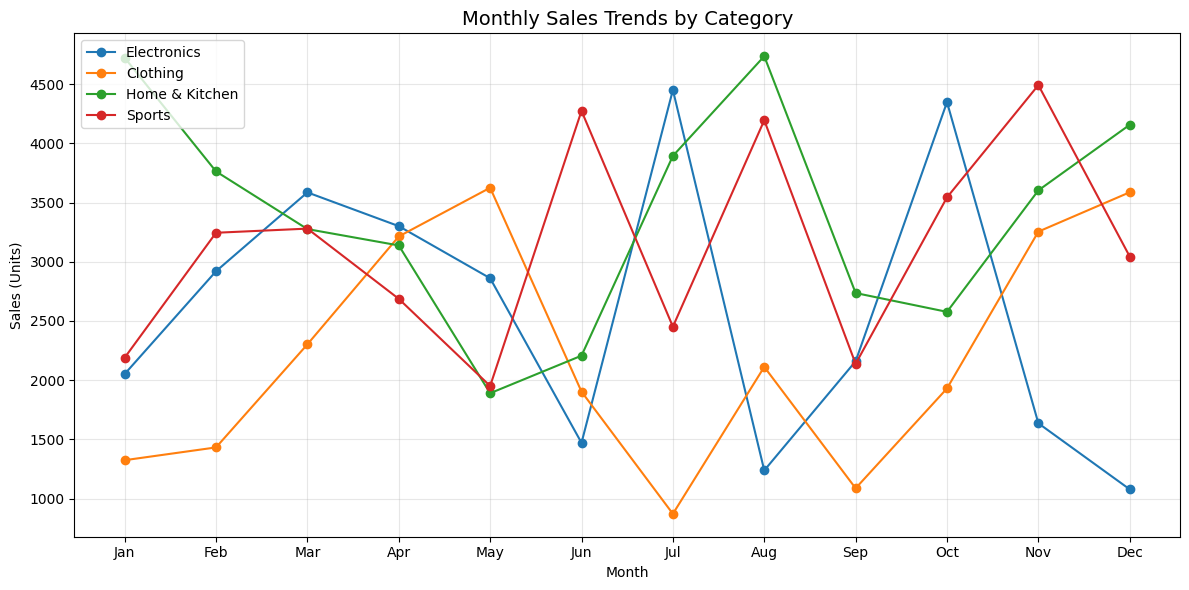

Line plot saved as sales_trends.png


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
for col in ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']:
    ax.plot(df.index, df[col], marker='o', label=col)

ax.set_title('Monthly Sales Trends by Category', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Sales (Units)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_trends.png', dpi=100, bbox_inches='tight')
plt.show()
print("Line plot saved as sales_trends.png")

### Plot 2: Box Plots - Sales Distribution per Category

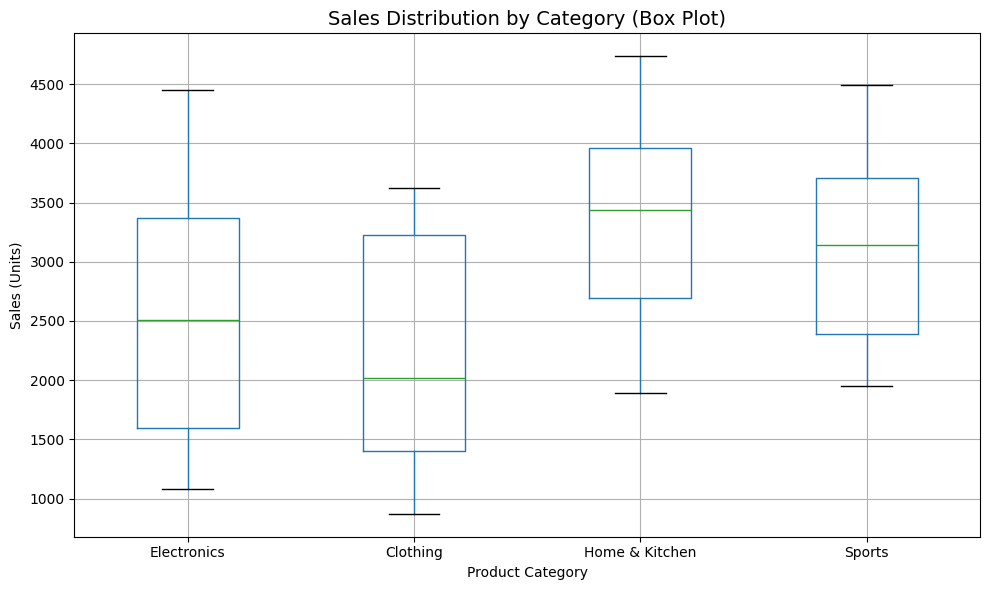

Box plot saved as sales_boxplot.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
df[['Electronics', 'Clothing', 'Home & Kitchen', 'Sports']].boxplot(ax=ax)
ax.set_title('Sales Distribution by Category (Box Plot)', fontsize=14)
ax.set_xlabel('Product Category')
ax.set_ylabel('Sales (Units)')
plt.tight_layout()
plt.savefig('sales_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print("Box plot saved as sales_boxplot.png")

## Q2: Array Operations

In [12]:
array = np.array([[1, -2, 3], [-4, 5, -6]])
print("Original Array:")
print(array)

print("\ni. Element-wise Absolute Value:")
print(np.abs(array))

print("\nii. Percentiles:")
for p in [25, 50, 75]:
    print(f"  {p}th percentile (flattened): {np.percentile(array, p)}")
    print(f"  {p}th percentile (each column): {np.percentile(array, p, axis=0)}")
    print(f"  {p}th percentile (each row): {np.percentile(array, p, axis=1)}")

print("\niii. Statistical Measures:")
print(f"  Mean (flattened): {np.mean(array):.4f}")
print(f"  Mean (each column): {np.mean(array, axis=0)}")
print(f"  Mean (each row): {np.mean(array, axis=1)}")
print(f"  Median (flattened): {np.median(array):.4f}")
print(f"  Median (each column): {np.median(array, axis=0)}")
print(f"  Median (each row): {np.median(array, axis=1)}")
print(f"  Std Dev (flattened): {np.std(array):.4f}")
print(f"  Std Dev (each column): {np.std(array, axis=0)}")
print(f"  Std Dev (each row): {np.std(array, axis=1)}")

Original Array:
[[ 1 -2  3]
 [-4  5 -6]]

i. Element-wise Absolute Value:
[[1 2 3]
 [4 5 6]]

ii. Percentiles:
  25th percentile (flattened): -3.5
  25th percentile (each column): [-2.75 -0.25 -3.75]
  25th percentile (each row): [-0.5 -5. ]
  50th percentile (flattened): -0.5
  50th percentile (each column): [-1.5  1.5 -1.5]
  50th percentile (each row): [ 1. -4.]
  75th percentile (flattened): 2.5
  75th percentile (each column): [-0.25  3.25  0.75]
  75th percentile (each row): [2.  0.5]

iii. Statistical Measures:
  Mean (flattened): -0.5000
  Mean (each column): [-1.5  1.5 -1.5]
  Mean (each row): [ 0.66666667 -1.66666667]
  Median (flattened): -0.5000
  Median (each column): [-1.5  1.5 -1.5]
  Median (each row): [ 1. -4.]
  Std Dev (flattened): 3.8622
  Std Dev (each column): [2.5 3.5 4.5]
  Std Dev (each row): [2.05480467 4.78423336]


## Q3: Floor, Ceiling, Truncated, Rounded Values

In [13]:
a = np.array([-1.8, -1.6, -0.5, 0.5, 1.6, 1.8, 3.0])
print("Original Array:", a)
print("Floor values:    ", np.floor(a))
print("Ceiling values:  ", np.ceil(a))
print("Truncated values:", np.trunc(a))
print("Rounded values:  ", np.round(a))

Original Array: [-1.8 -1.6 -0.5  0.5  1.6  1.8  3. ]
Floor values:     [-2. -2. -1.  0.  1.  1.  3.]
Ceiling values:   [-1. -1. -0.  1.  2.  2.  3.]
Truncated values: [-1. -1. -0.  0.  1.  1.  3.]
Rounded values:   [-2. -2. -0.  0.  2.  2.  3.]


## Q4: Swap Two Elements in a List Using Temporary Variable

In [14]:
def swap_list_temp(lst, i, j):
    temp = lst[i]
    lst[i] = lst[j]
    lst[j] = temp
    return lst

my_list = [10, 20, 30, 40, 50]
print("Original list:", my_list)
swap_list_temp(my_list, 1, 3)
print("After swapping index 1 and 3:", my_list)

Original list: [10, 20, 30, 40, 50]
After swapping index 1 and 3: [10, 40, 30, 20, 50]


## Q5: Swap Two Elements in a Set (via List Conversion)

In [15]:
def swap_set_elements(s, elem1, elem2):
    lst = list(s)
    if elem1 in lst and elem2 in lst:
        i, j = lst.index(elem1), lst.index(elem2)
        lst[i], lst[j] = lst[j], lst[i]  # swap
        return set(lst)
    else:
        print("One or both elements not in set.")
        return s

my_set = {10, 20, 30, 40, 50}
print("Original set:", my_set)
result = swap_set_elements(my_set, 20, 40)
print("After swapping 20 and 40:", result)
print("Note: Sets are unordered, so visual order may vary.")

Original set: {50, 20, 40, 10, 30}
After swapping 20 and 40: {40, 10, 50, 20, 30}
Note: Sets are unordered, so visual order may vary.
